# Figure 4
Time series of temperature, humidity, and aerosol mass from model output and MOSAiC measurements.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

# Read measurement data

In [2]:
def read_mosaic_aero_mass(fname, header, species, columns, flag_label, tslice, freq):
    data = pd.read_csv(fname, header=header, sep="\t")
    data["Date/Time"] = pd.to_datetime(data["Date/Time"])
    data = data.set_index("Date/Time").to_xarray()
    data = data.rename(columns)
    data = data.sel(time=tslice)

    data_resample = data.resample(time=freq).mean()
    data_resample = data_resample[species]

    data_masked = data[species].where(data[flag_label]!=1)
    data_masked_resample = data_masked.resample(time=freq).mean()
    
    return data_resample, data_masked_resample

In [3]:
apr = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))

ams_columns = {  # used for cleaner column names
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    '[SO4]2- [µg/m**3]': 'so4',
    '[NO3]- [µg/m**3]': 'no3',
    '[NH4]+ [µg/m**3]': 'nh4',
    'Cl- [µg/m**3]': 'cl',
    'Org aerosol [µg/m**3]': 'org',
    'QF [NH4]+': 'nh4_qc',  # 1=good, 0=bad
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
flag = "pollution_qc"
ams_fname = "/mnt/data/mosaic/AMS_5species_noscaling.tab"
ams_data_1h, ams_masked_1h = read_mosaic_aero_mass(ams_fname, 51, ["so4","org"], ams_columns, flag, apr, "1h")

ebc_columns = {
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'eBC [ng/m**3]': 'ebc',
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
ebc_fname = "/mnt/data/mosaic//MOSAiC_eBC.tab"
ebc_data_1h, ebc_masked_1h = read_mosaic_aero_mass(ebc_fname, 42, "ebc", ebc_columns, flag, apr, "1h")


In [9]:
mosaic_met = xr.open_dataset("/mnt/data/mosaic/jozef_lower_atmos/MOSAiC_Atm_Properties.nc")
mosaic_met = mosaic_met.sel(time=apr)

mosaic_nav = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic_nav = mosaic_nav.assign_coords({"day": ("time", [T.dt.day for T in mosaic_nav.time])})

# Read model output

In [19]:
vars_to_load = [
    "P",
    "PB",
    "PH",
    "PHB",
    "T",
    "QVAPOR",
    "so4_a01",
    "so4_a02",
    "so4_a03",
    "so4_a04",
    "so4_cw01",
    "so4_cw02",
    "so4_cw03",
    "so4_cw04",
    "bc_a01",
    "bc_a02",
    "bc_a03",
    "bc_a04",
    "bc_cw01",
    "bc_cw02",
    "bc_cw03",
    "bc_cw04",
    "oc_a01",
    "oc_a02",
    "oc_a03",
    "oc_a04",
    "oc_cw01",
    "oc_cw02",
    "oc_cw03",
    "oc_cw04",
    "TOTOA_A01",
    "TOTOA_A02",
    "TOTOA_A03",
    "TOTOA_A04",
    "TOTOA_CW01",
    "TOTOA_CW02",
    "TOTOA_CW03",
    "TOTOA_CW04",
]

wrfout_mean = []
wrfout_min = []
wrfout_max = []

for v in vars_to_load:
    print(v)
    var_mean = []
    var_min = []
    var_max = []
    fname = f"/mnt/data/model_output/NO_BLOW_SNOW/{v}_2020-04-10_2020-04-19.nc"
    with xr.open_dataset(fname).set_index(Time="XTIME") as wrfout_grid:
        mosaic_coords = mosaic_nav.sel(time=wrfout_grid.Time)

        for i in range(len(wrfout_grid.Time)):
            wrfout_ts = wrfout_grid.isel(Time=i).compute()
            mosaic_ts = mosaic_coords.isel(Time=i)
            var_mean.append(wrfout_ts.wrf.value_around_point(
                lon=mosaic_ts.Longitude,
                lat=mosaic_ts.Latitude,
                method="mean"
            ))
            var_min.append(wrfout_ts.wrf.value_around_point(
                lon=mosaic_ts.Longitude,
                lat=mosaic_ts.Latitude,
                method="min"
            ))
            var_max.append(wrfout_ts.wrf.value_around_point(
                lon=mosaic_ts.Longitude,
                lat=mosaic_ts.Latitude,
                method="max"
            ))
    wrfout_mean.append(xr.concat(var_mean, dim="Time"))
    wrfout_min.append(xr.concat(var_min, dim="Time"))
    wrfout_max.append(xr.concat(var_max, dim="Time"))

wrfout_mean = xr.merge(wrfout_mean)
wrfout_min = xr.merge(wrfout_min)
wrfout_max = xr.merge(wrfout_max)



P
PB
PH
PHB
T
QVAPOR
so4_a01
so4_a02
so4_a03
so4_a04
so4_cw01
so4_cw02
so4_cw03
so4_cw04
bc_a01
bc_a02
bc_a03
bc_a04
bc_cw01
bc_cw02
bc_cw03
bc_cw04
oc_a01
oc_a02
oc_a03
oc_a04
oc_cw01
oc_cw02
oc_cw03
oc_cw04
TOTOA_A01
TOTOA_A02
TOTOA_A03
TOTOA_A04
TOTOA_CW01
TOTOA_CW02
TOTOA_CW03
TOTOA_CW04


In [25]:
for ds in [wrfout_mean, wrfout_min, wrfout_max]:
    ds["rho_air"] = ds.wrf.density_of_dry_air[:]
    ds["air_temperature"] = ds.wrf.air_temperature[:]


## interpolate from WRF-Chem-Polar aerosol bins to PM1 size range

In [21]:
def make_bin_dimension(ds_wrf, species, nbins=4):
    aname, cwname = species+"_a", species+"_cw"

    # convert a0X output for this species to one array with new bin dimension
    aer_vars = [v for v in ds_wrf.data_vars if aname in v.lower()]
    array_aer = ds_wrf[aer_vars].to_array(dim="bin")
    array_aer["bin"] = np.arange(nbins)

    # cw0X variables
    cld_vars = [v for v in ds_wrf.data_vars if cwname in v.lower()]
    array_cld = ds_wrf[cld_vars].to_array(dim="bin")
    array_cld["bin"] = np.arange(nbins)

    # add new variables to new dataset
    ds_binned = xr.Dataset()
    ds_binned[species] = array_aer+array_cld

    # add bin size coordinates for new dimension
    [dlo, dmid, dhi] = utils.calc_mosaic_size_bins()    
    ds_binned = ds_binned.assign_coords({
        "Dlo": ("bin", dlo),
        "Dmid": ("bin", dmid),
        "Dhi": ("bin", dhi),
        "dD": ("bin", dhi-dlo)
    })

    return ds_binned

def sum_wrf_aero_bins(ds_binned, cutoff=1):
    if "bin" not in ds_binned.dims:
        msg = "[sum_wrf ERROR] no bin dimension on the dataset"
        raise ValueError(msg)
        return
    nbins = len(ds_binned.bin)
    bin_bounds = np.zeros((nbins+1))
    bin_bounds[:-1] = ds_binned.Dlo.values
    bin_bounds[-1] = ds_binned.Dhi.values[-1]

    # find size bin containing cutoff
    i = np.searchsorted(bin_bounds, cutoff)-1

    # sum up to cutoff
    ds_sum = ds_binned.isel(bin=slice(None,i)).sum(dim="bin")

    # add linear fraction of bin containing cutoff
    ibin_width = ds_binned.Dhi.values[i] - ds_binned.Dlo.values[i]
    f = (cutoff - ds_binned.Dlo.values[i]) / ibin_width
    ds_sum += f*ds_binned.isel(bin=i, drop=True)
    
    return ds_sum



In [23]:
for ds in [wrfout_mean, wrfout_min, wrfout_max]:
    ds["so4"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "so4")).so4
    ds["bc"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "bc")).bc
    ds["oc"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "oc")).oc
    ds["toa"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "totoa")).totoa


AttributeError: 'Dataset' object has no attribute 'rho_air'

In [26]:
ds = wrfout_mean
ds["so4"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "so4")).so4
ds["bc"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "bc")).bc
ds["oc"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "oc")).oc
ds["toa"] = ds.rho_air*sum_wrf_aero_bins(make_bin_dimension(ds, "totoa")).totoa


## Read CESM and CAMS data
Position of Polarstern was extracted in `extract-mosaic-cams.ipynb` and `extract-mosaic-cesm.ipynb`.

In [27]:
cams = xr.open_dataset("/mnt/data/cams/cams_mosaic.nc").sel(time=apr)
cams_mosaic_mean = cams.mean(["i","j"])
cams_mosaic_min = cams.min(["i","j"])
cams_mosaic_max = cams.max(["i","j"])

cesm = xr.open_dataset("/mnt/data/cesm/cesm_mosaic.nc").sel(time=apr)
cesm_mosaic_mean = cesm.mean(["i","j"])
cesm_mosaic_min = cesm.min(["i","j"])
cesm_mosaic_max = cesm.max(["i","j"])

cams_mass_conc_mean = cams_mosaic_mean.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_min = cams_mosaic_min.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_max = cams_mosaic_max.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_mean = cesm_mosaic_mean.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_min = cesm_mosaic_min.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_max = cesm_mosaic_max.interp(time=wrfout_mean.Time) * wrfout_mean.rho_air.isel(bottom_top=0)

# make figure

In [28]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


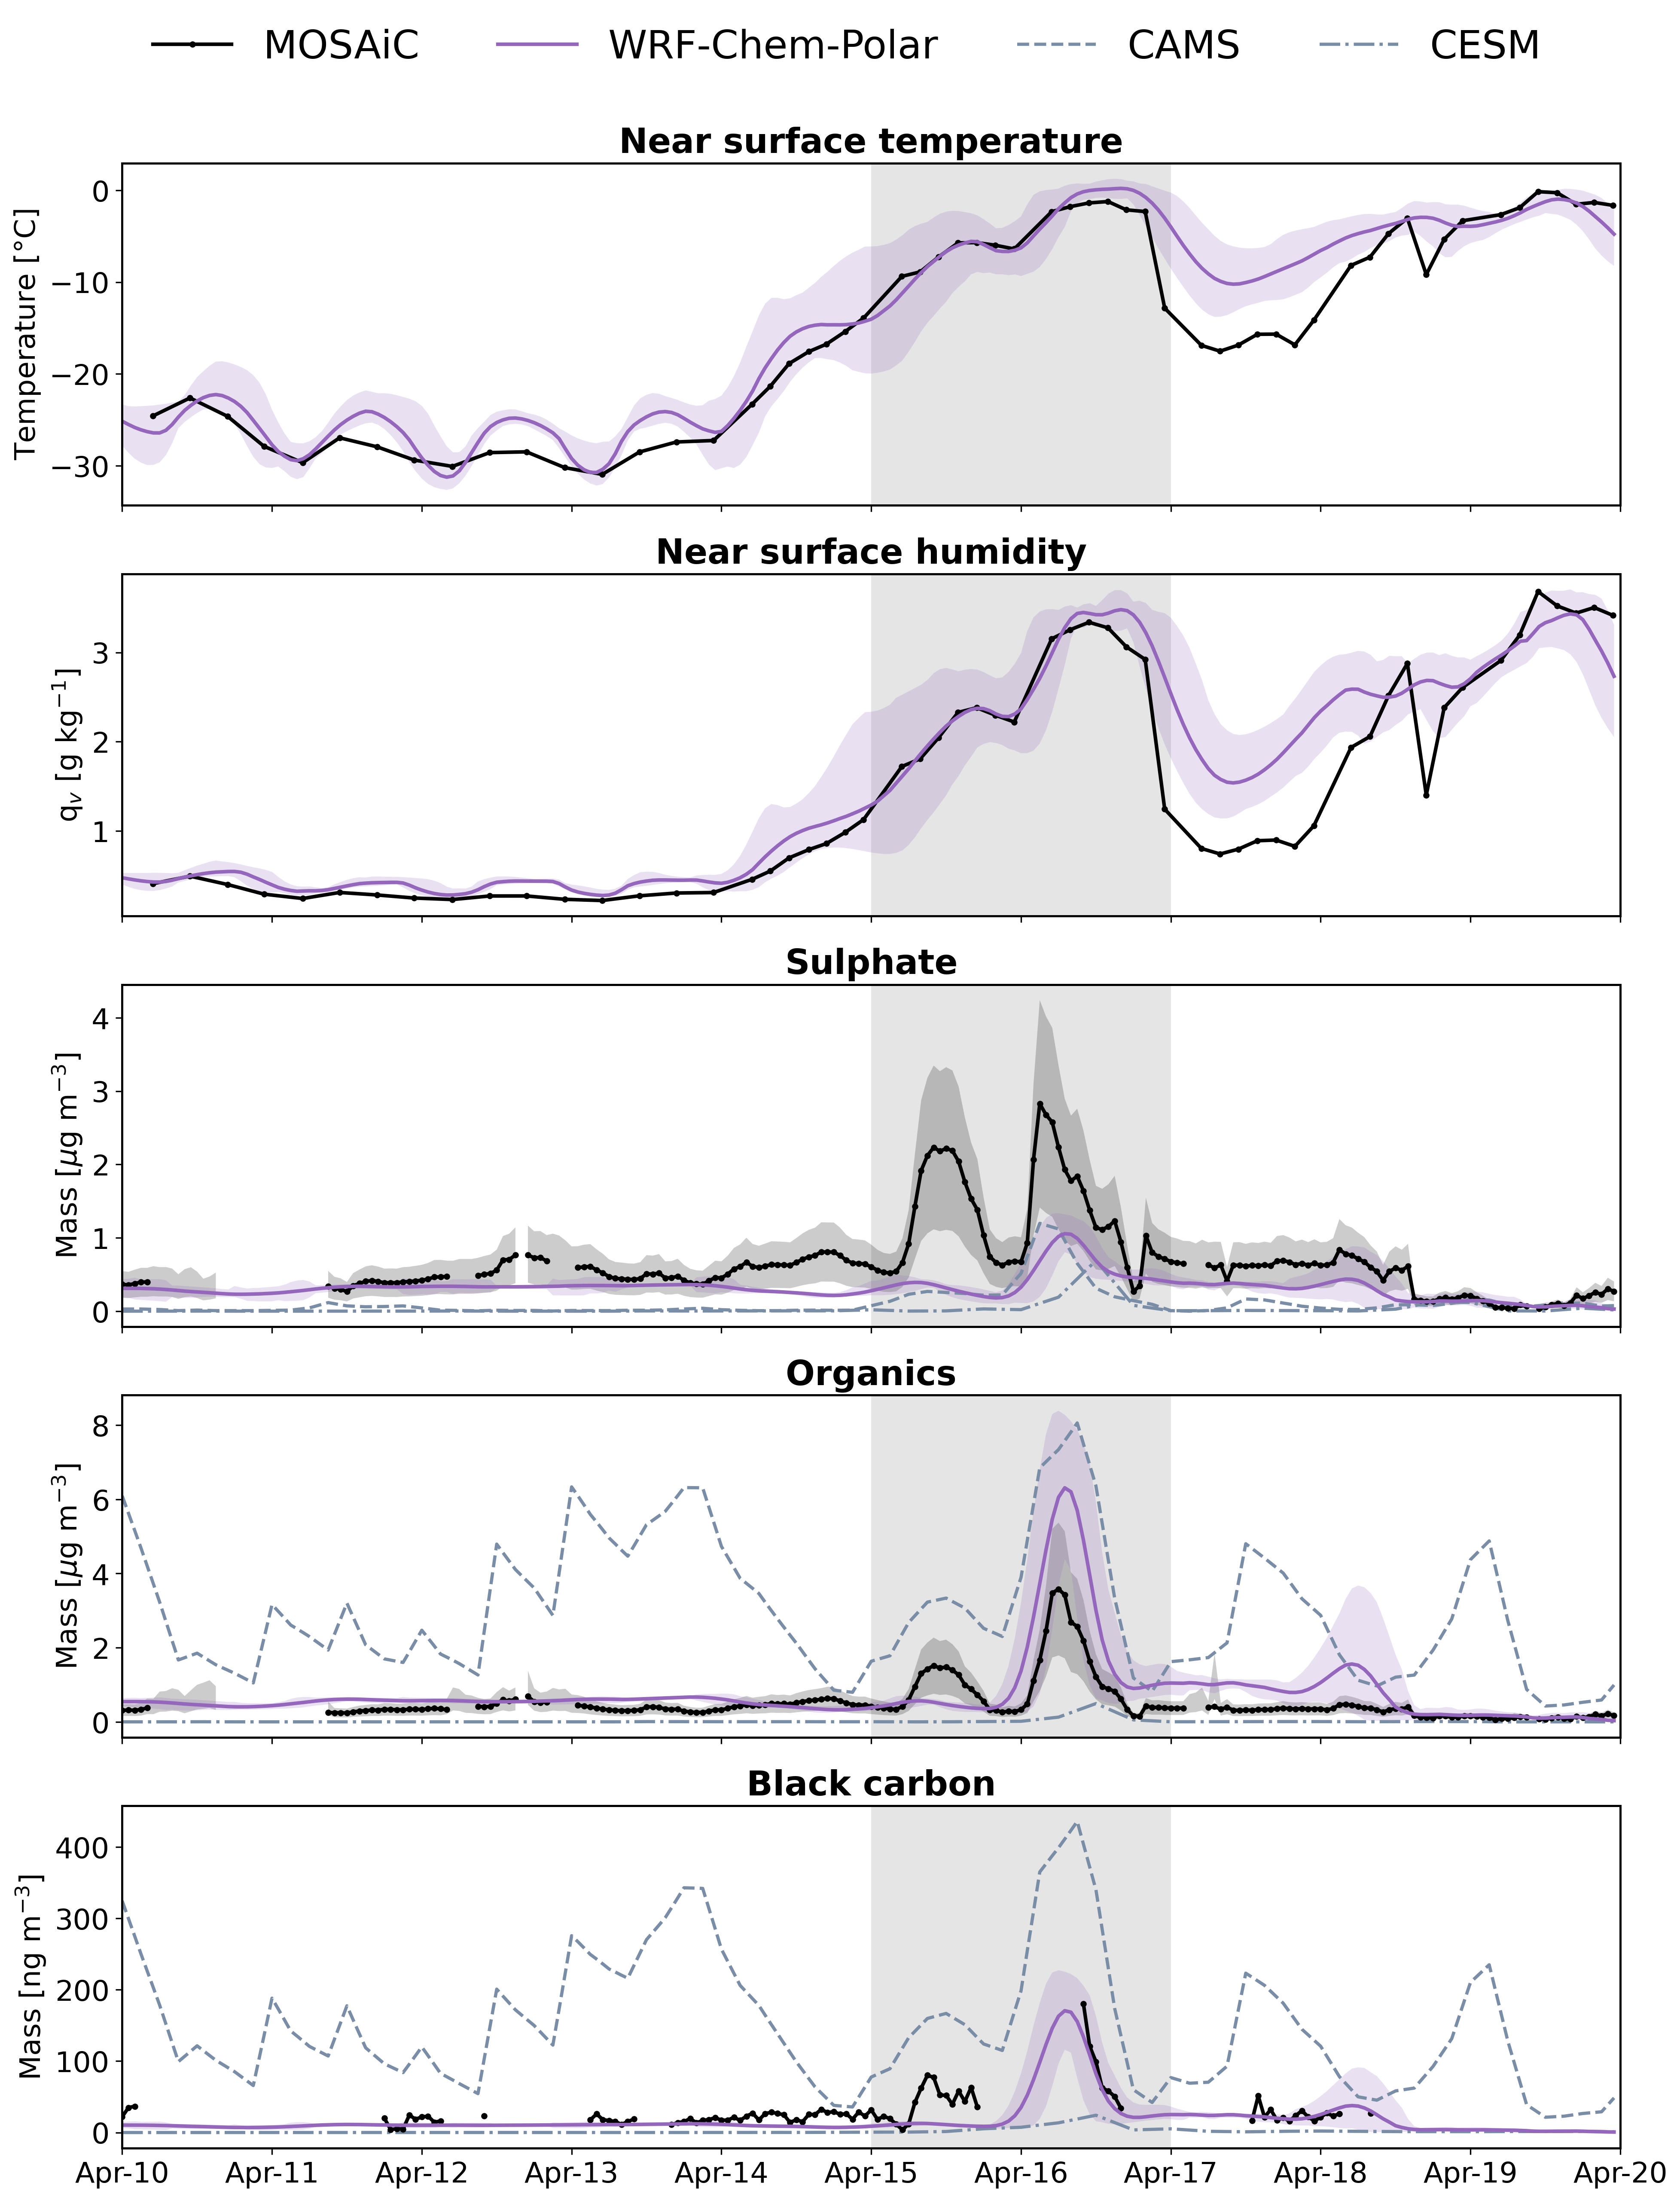

In [30]:
alpha, lw, ms = 0.1, 1.8, 5
c_input_data = "#7A8DA6"


fig, axes = plt.subplots(5, 1, figsize=(15,20), dpi=300)

for ax in axes:
    ax.axvspan(
        dt.datetime(2020,4,15),
        dt.datetime(2020,4,17),
        color="black",
        alpha=0.1,
        ec="None"
    )


### TEMPERATURE

axes[0].plot(
    mosaic_met.time,
    mosaic_met.t_10m,
    "k",
    marker=".",
    ms=ms,
    label="MOSAiC"
)
axes[0].plot(
    wrfout_mean.Time,
    wrfout_mean.air_temperature.isel(bottom_top=0)-273.15,
    c="tab:purple",
    label="WRF-Chem-Polar"
)
axes[0].fill_between(
    wrfout_mean.Time,
    wrfout_min.air_temperature.isel(bottom_top=0)-273.15,
    wrfout_max.air_temperature.isel(bottom_top=0)-273.15,
    color="tab:purple",
    alpha=0.2,
    edgecolor="None"
)
axes[0].set_ylabel("Temperature [$\\degree$C]")
axes[0].set_title("Near surface temperature", weight="bold")


### HUMIDITY

axes[1].plot(
    mosaic_met.time,
    mosaic_met.r_10m,
    "k",
    marker=".",
    ms=ms
)
axes[1].plot(
    wrfout_mean.Time,
    wrfout_mean.QVAPOR.isel(bottom_top=0)*1e3,
    c="tab:purple",
)
axes[1].fill_between(
    wrfout_mean.Time,
    wrfout_min.QVAPOR.isel(bottom_top=0)*1e3,
    wrfout_max.QVAPOR.isel(bottom_top=0)*1e3,
    color="tab:purple",
    alpha=0.2,
    edgecolor="None"
)
axes[1].set_ylabel("q$_v$ [g kg$^{{-1}}$]")
axes[1].set_title("Near surface humidity", weight="bold")


### AEROSOL MASS
f_ams = 0.65
std_ams = 0.5

# sulphate
lcams, = axes[2].plot(
    wrfout_mean.Time,
    1e9*cams_mass_conc_mean.so4,
    c=c_input_data,
    ls="dashed",
    label="CAMS",
    linewidth=lw,
)
lcesm, = axes[2].plot(
    wrfout_mean.Time,
    1e9*cesm_mass_conc_mean.so4.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    label="CESM",
    linewidth=lw
)
axes[2].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.so4-std_ams*f_ams*ams_data_1h.so4,
    f_ams*ams_data_1h.so4+std_ams*f_ams*ams_data_1h.so4,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
lmosaic, = axes[2].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.so4,
    'k',
    label='MOSAiC',
    marker=".",
    ms=ms
)
lwrf, = axes[2].plot(
    wrfout_mean.Time,
    wrfout_mean.so4.isel(bottom_top=0),
    c="tab:purple",
    label="WRF-Chem-Polar"
)
axes[2].fill_between(
    wrfout_mean.Time,
    wrfout_min.so4.isel(bottom_top=0),
    wrfout_max.so4.isel(bottom_top=0),
    color="tab:purple",
    alpha=0.2,
    edgecolor="None"
)
axes[2].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[2].set_title("Sulphate", weight="bold")

# oc
axes[3].plot(
    wrfout_mean.Time,
    1e9*(cams_mass_conc_mean.oc_hydrophilic+cams_mass_conc_mean.oc_hydrophobic),
    c=c_input_data,
    ls="dashed",
    linewidth=lw,
    label="CAMS hydrophilic+hydrophobic"
)
axes[3].plot(
    wrfout_mean.Time,
    1e9*cesm_mass_conc_mean.oc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw,
)
axes[3].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.org-std_ams*f_ams*ams_data_1h.org,
    f_ams*ams_data_1h.org+std_ams*f_ams*ams_data_1h.org,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.org,
    'k',
    marker=".",
    ms=ms
)
axes[3].fill_between(
    wrfout_mean.Time,
    (wrfout_min.toa+wrfout_min.oc).isel(bottom_top=0),
    (wrfout_max.toa+wrfout_max.oc).isel(bottom_top=0),
    color="tab:purple",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    wrfout_mean.Time,
    (wrfout_mean.toa+wrfout_mean.oc).isel(bottom_top=0),
    c="tab:purple",
    label="WFR-Chem-Polar"
)
axes[3].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[3].set_title("Organics", weight="bold")

# bc

axes[4].plot(
    wrfout_mean.Time,
    1e12*(cams_mass_conc_mean.bc_hydrophilic+cams_mass_conc_mean.bc_hydrophobic),
    c=c_input_data,
    label="CAMS all",
    ls="dashed",
    linewidth=lw
)
axes[4].plot(
    wrfout_mean.Time,
    1e12*cesm_mass_conc_mean.bc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw
)
axes[4].plot(
    ebc_masked_1h.time,
    f_ams*ebc_masked_1h,
    'k',
    marker=".",
    ms=ms
)
axes[4].plot(
    wrfout_mean.Time,
    wrfout_mean.bc.isel(bottom_top=0)*1e3,
    c="tab:purple",
    label="WRF-Chem-Polar"
)
axes[4].fill_between(
    wrfout_mean.Time,
    wrfout_min.bc.isel(bottom_top=0)*1e3,
    wrfout_max.bc.isel(bottom_top=0)*1e3,
    color="tab:purple",
    alpha=0.2,
    edgecolor="None"
)
axes[4].set_ylabel("Mass [ng m$^{{-3}}$]")
axes[4].set_title("Black carbon", weight="bold")

fig.legend(
    ncols=4,
    handles=[lmosaic,lwrf,lcams,lcesm],
    loc="center",
    bbox_to_anchor=(0, 0.9, 1, 0.05),
    edgecolor="None",
    borderaxespad=0.25,
    fontsize=22
)
for ax in axes:
    ax.set_xlim(apr.start, apr.stop)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
for ax in axes[:-1]:
    ax.set_xticklabels([])

plt.savefig(f"../../figures/figure4_noblowsnow.png", bbox_inches="tight")
